In [16]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [17]:
def read_h5_file(output_file):
    simulation_data = {}
    with h5py.File(output_file, 'r') as f:
        # Read global attributes safely
        attributes = {
            "total_chicken_population": f.attrs.get("total_chicken_population", None),
            "duck_symptomatic_probability": f.attrs.get("duck_symptomatic_probability", None),
        }

        # Iterate over simulation groups
        for sim_name in f:
            sim_group = f[sim_name]
            
            if "time" in sim_group and "state" in sim_group:
                t = sim_group["time"][:]
                y = sim_group["state"][:]
                simulation_data[sim_name] = {"time": t, "state": y}
            else:
                print(f"Warning: Missing 'time' or 'state' in {sim_name}")

    return simulation_data, attributes

In [18]:
def if_outbreak(t, y, outbreak_threshold=5):
    """Determine if an outbreak occurs based on the final time step."""
    return np.sum(y[-1, :, :, 5:]) >= outbreak_threshold

In [19]:
def passive_surveillance(t, y, alert_threshold=2):
    """Find the first time passive surveillance detects an outbreak."""
    threshold_reached = np.where(np.sum(y[:, :, :, 6], axis=(1, 2)) >= alert_threshold)[0]

    if len(threshold_reached) > 0:
        return t[threshold_reached[0]], np.trapz(np.sum(y[:threshold_reached[0]+1, :, :, 3:5], axis=(1, 2, 3)), t[:threshold_reached[0]+1])
    else:
        return np.nan, np.nan


In [20]:
def create_df(simulation_data):
    """Create a DataFrame summarizing outbreak and detection times and store associated states."""
    results = []

    for sim_name, data in simulation_data.items():
        outbreak = if_outbreak(data["time"], data["state"])
        
        pas_2, y2 = passive_surveillance(data["time"], data["state"], alert_threshold=2)
        pas_4, y4 = passive_surveillance(data["time"], data["state"], alert_threshold=4)
        pas_6, y6 = passive_surveillance(data["time"], data["state"], alert_threshold=6)
        
        final_deaths = np.sum(data["state"][-1, :, :, 6:])
        final_removed = np.sum(data["state"][-1, :, :, 5:])

        results.append([sim_name, outbreak, pas_2, y2, pas_4, y4, pas_6, y6, final_deaths, final_removed])

    # Create DataFrame
    df = pd.DataFrame(results, columns=[
        "simulation", "outbreak", 
        "passive_surveillance_threshold_2", "y2_state", 
        "passive_surveillance_threshold_4", "y4_state", 
        "passive_surveillance_threshold_6", "y6_state",
        "final_deaths", "final_removed"
    ])

    # Convert detection time columns to numeric
    for col in ["passive_surveillance_threshold_2", "passive_surveillance_threshold_4", "passive_surveillance_threshold_6"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")  # Ensures NaNs are properly handled

    return df

In [21]:
# List of files corresponding to different chicken populations

index_range = range(50)


file_template = "Raw_simu_files/chicken_0_symprob_0.2_totpop_40_rand_1_index_{}_freq_0.h5"

def process_files(index_range):
    all_results = []

    for index in index_range:
        output_file = file_template.format(index)
        simulation_data, attributes = read_h5_file(output_file)  # Read H5 file

        df = create_df(simulation_data)  # Create DataFrame
        df["index"] = index  # Add index info

        all_results.append(df)  # Append to results list

    # Combine all into a single DataFrame
    combined_df = pd.concat(all_results, ignore_index=True)
    return combined_df

# Run the function
df_all = process_files(index_range)




In [22]:
# Function to compute detection time
def compute_detection_time(output_file, threshold):
    try:
        with h5py.File(output_file, 'r') as f:
            detection_times = []
            for sim_name in f:
                if "state" in f[sim_name]:
                    state = f[sim_name]["state"][:]  # shape: (T, x, y, C)
                    times = f[sim_name]["time"][:]
                    deaths = np.sum(state[:, :, :, 6], axis=(1, 2))  # deaths over time
                    detected = np.where(deaths >= threshold)[0]
                    if detected.size > 0:
                        detection_times.append(times[detected[0]])
            return np.mean(detection_times) if detection_times else np.nan
    except FileNotFoundError:
        print(f"Missing file: {output_file}")
        return np.nan


In [23]:
def compute_burden(output_file, threshold):
    try:
        with h5py.File(output_file, 'r') as f:
            burdens = []
            for sim_name in f:
                if "state" in f[sim_name]:
                    y = f[sim_name]["state"][:]
                    t = f[sim_name]["time"][:]
                    cum_deaths = np.sum(y[:, :, :, 6], axis=(1, 2))
                    detect_idx = np.where(cum_deaths >= threshold)[0]
                    if detect_idx.size > 0:
                        stop = detect_idx[0] + 1
                        infectious = np.sum(y[:stop, :, :, 3:5], axis=(1, 2, 3))  # symptomatic + asymptomatic
                        burden = np.trapz(infectious, t[:stop])
                        burdens.append(burden)
            return np.mean(burdens) if burdens else np.nan
    except FileNotFoundError:
        print(f"Missing file: {output_file}")
        return np.nan




In [24]:
param_grid = np.load("param_grid.npy", allow_pickle=True)

param_names = [
    "beta_cc", "sigma_c_inv", "gamma_c_inv",
    "beta_dd", "sigma_d_inv", "gamma_d_inv",
    "delta_d", "kappa"
]



# Convert param_grid to DataFrame
param_df = pd.DataFrame(param_grid, columns=param_names)
param_df["index"] = range(len(param_df))

# Merge with outcomes
results_df = df_all.merge(param_df, on="index", how="left")



In [25]:
# Example: correlate parameters with final deaths
corr = results_df[param_names + ["final_deaths"]].corr(method="spearman")
param_corr = corr["final_deaths"].drop("final_deaths").sort_values()



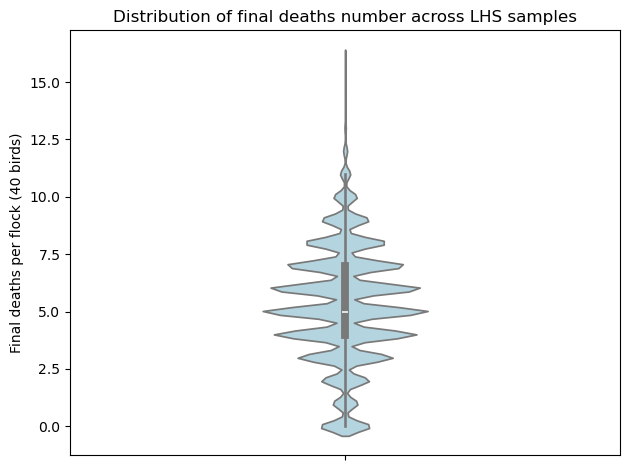

In [26]:

sns.violinplot(y=df_all["final_deaths"], color="lightblue", width=0.3)
plt.ylabel("Final deaths per flock (40 birds)")
plt.title("Distribution of final deaths number across LHS samples")
plt.tight_layout()
plt.show()


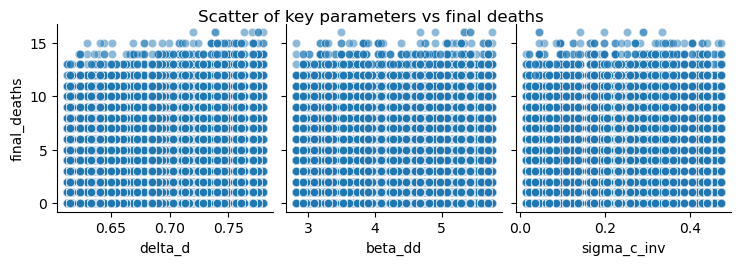

In [27]:
top_params = param_corr.abs().sort_values(ascending=False).head(3).index

sns.pairplot(results_df, x_vars=top_params, y_vars=["final_deaths"],
             kind="scatter", plot_kws={"alpha":0.5})
plt.suptitle("Scatter of key parameters vs final deaths", y=1.02)
plt.show()


C:\Users\XingY\AppData\Local\Temp\ipykernel_8296\3813330971.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\XingY\AppData\Local\Temp\ipykernel_8296\3813330971.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\XingY\AppData\Local\Temp\ipykernel_8296\3813330971.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


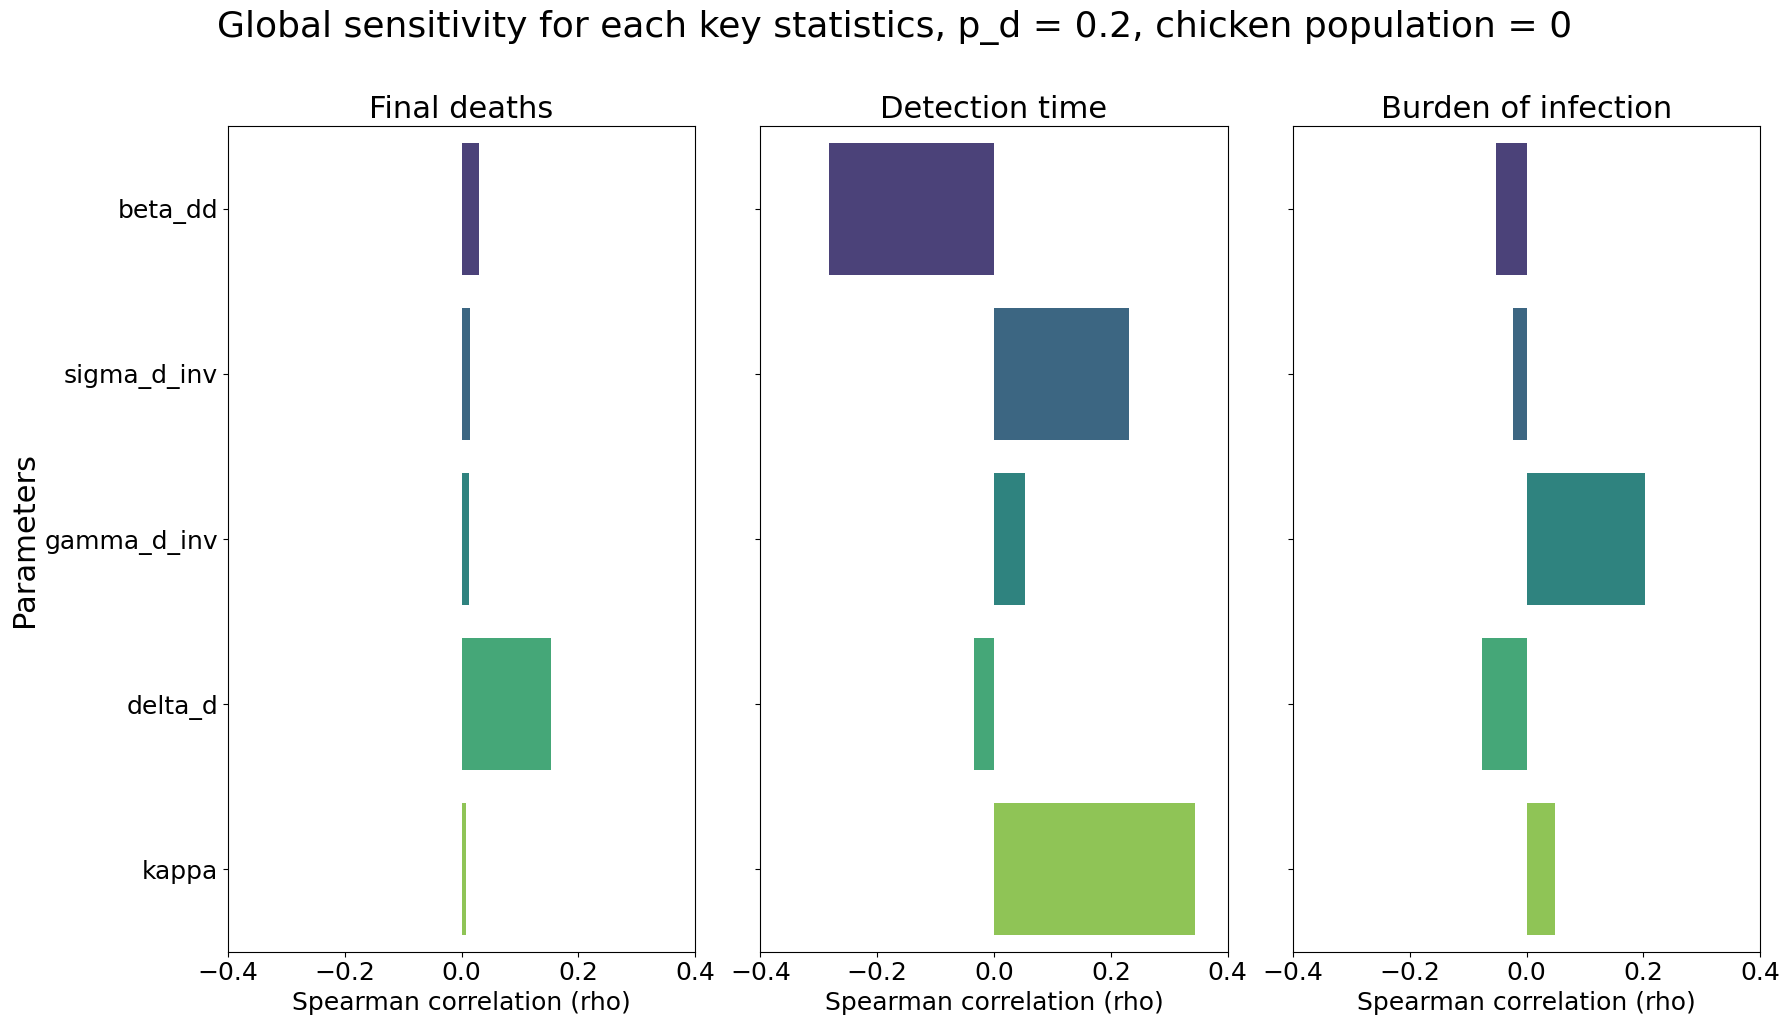

In [28]:

# --- Correlation with detection time ---
corr_detection = results_df[param_names + ["passive_surveillance_threshold_2"]].corr(method="spearman")
param_corr_detection = corr_detection["passive_surveillance_threshold_2"].drop("passive_surveillance_threshold_2").sort_values()

top_params = param_corr_detection.abs().sort_values(ascending=False).head(3).index

# sns.pairplot(results_df, x_vars=top_params, y_vars=["passive_surveillance_threshold_2"],
#              kind="scatter", plot_kws={"alpha":0.5})
# plt.suptitle("Scatter of key parameters vs Detection time (detection threshold 2)", y=1.02)
# plt.show()


# --- Correlation with burden ---
corr_burden = results_df[param_names + ["y2_state"]].corr(method="spearman")
param_corr_burden = corr_burden["y2_state"].drop("y2_state").sort_values()

top_params = param_corr_burden.abs().sort_values(ascending=False).head(3).index

# sns.pairplot(results_df, x_vars=top_params, y_vars=["y2_state"],
#              kind="scatter", plot_kws={"alpha":0.5})
# plt.suptitle("Scatter of key parameters vs burden of infection until detection", y=1.02)
# plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
for ax in axes:
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=18)  # <-- increase y-axis font size
    ax.tick_params(axis="x", labelsize=18)  # optional, x-axis tick labels
# choose which parameters to keep
keep_params = ["beta_dd", "sigma_d_inv", "gamma_d_inv",
    "delta_d", "kappa"
]

# --- Final deaths ---
sns.barplot(
    x=param_corr[keep_params].values,
    y=param_corr[keep_params].index,
    palette="viridis",
    order=keep_params,
    ax=axes[0],
)
axes[0].set_xlabel("Spearman correlation (rho)", fontsize=18)
axes[0].set_title("Final deaths", fontsize=22)
axes[0].set_xlim(-0.4, 0.4)

# --- Detection time ---
sns.barplot(
    x=param_corr_detection[keep_params].values,
    y=param_corr_detection[keep_params].index,
    palette="viridis",
    order=keep_params,
    ax=axes[1],
)
axes[1].set_xlabel("Spearman correlation (rho)", fontsize=18)
axes[1].set_title("Detection time", fontsize=22)
axes[1].set_xlim(-0.4, 0.4)

# --- Burden of infection ---
sns.barplot(
    x=param_corr_burden[keep_params].values,
    y=param_corr_burden[keep_params].index,
    palette="viridis",
    order=keep_params,
    ax=axes[2],
)
axes[2].set_xlabel("Spearman correlation (rho)", fontsize=18)
axes[2].set_title("Burden of infection", fontsize=22)
axes[2].set_xlim(-0.4, 0.4)

# Shared formatting
for ax in axes:
    ax.set_ylabel("")
axes[0].set_ylabel("Parameters", fontsize=22)

plt.suptitle(f"Global sensitivity for each key statistics, p_d = 0.2, chicken population = 0", fontsize=26, y=1.02)
plt.tight_layout()
plt.show()

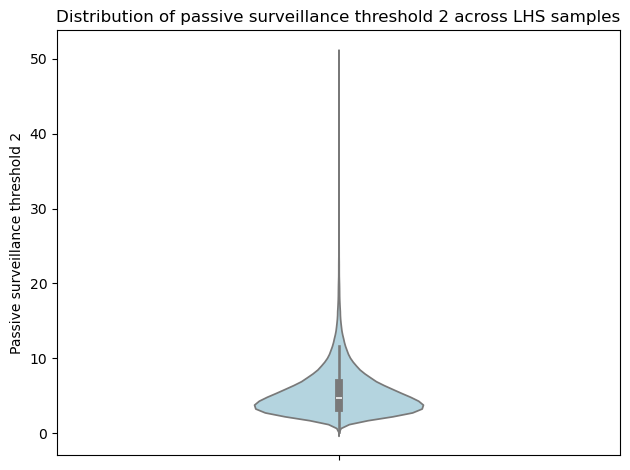

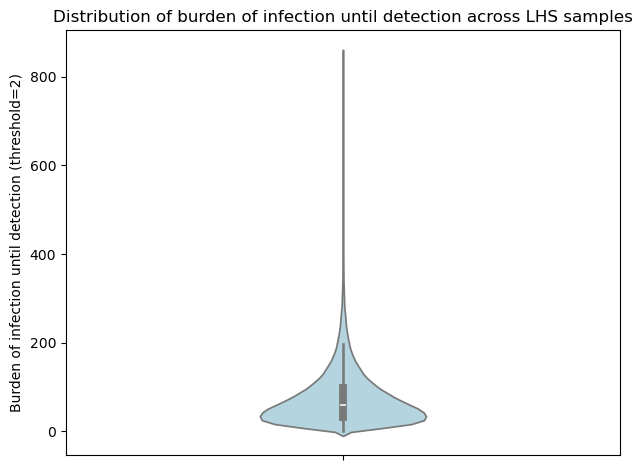

In [29]:

sns.violinplot(y=df_all["passive_surveillance_threshold_2"], color="lightblue", width=0.3)
plt.ylabel("Passive surveillance threshold 2")
plt.title("Distribution of passive surveillance threshold 2 across LHS samples")
plt.tight_layout()
plt.show()


sns.violinplot(y=df_all["y2_state"], color="lightblue", width=0.3)
plt.ylabel("Burden of infection until detection (threshold=2)")
plt.title("Distribution of burden of infection until detection across LHS samples")
plt.tight_layout()
plt.show()